# Partie 2 : Détection de Visage et Biais Algorithmique

**Date :** 27 avril 2026  
**Dataset :** Olivetti Faces (400 images, 40 personnes) + détection sur image réelle  
**Objectif :** Implémenter un modèle de détection de visage, apprendre les variables latentes, identifier et corriger les biais algorithmiques

---

## Table des matières

1. [Introduction et préparation](#section1)
2. [Détection de visage sur image réelle](#section2)
3. [Dataset Olivetti Faces et variables latentes](#section3)
4. [Modèle de classification de visages](#section4)
5. [Analyse des biais algorithmiques](#section5)
6. [Stratégies de correction des biais](#section6)
7. [Évaluation et considérations éthiques](#section7)

---

<a id='section1'></a>
## 1. Introduction et préparation

### Contexte
La détection et la reconnaissance de visages sont des tâches centrales en vision par ordinateur, utilisées dans des domaines aussi variés que la sécurité, les réseaux sociaux ou la médecine légale. Mais ces systèmes ne sont pas neutres : ils peuvent présenter des **biais algorithmiques** qui défavorisent certains groupes d'individus selon leurs conditions de prise de vue.

Dans ce projet, on s'intéresse à deux aspects :
1. **Détecter les visages** dans une image quelconque (approche générale)
2. **Reconnaître l'identité** d'une personne et analyser si le modèle est équitable pour tout le monde

### Variables latentes
Les variables cachées qui peuvent créer des biais dans la reconnaissance faciale sont :
- **La luminosité** : images sombres ou surexposées
- **Le contraste** : photos floues ou de mauvaise qualité
- **La pose / asymétrie** : visage légèrement de profil
- **L'expression** : sourire, yeux fermés, etc.

Ces variables ne sont pas les labels qu'on prédit, mais elles influencent silencieusement les performances du modèle.

### Approche
1. Détecter les visages dans `image.jpeg` avec **OpenCV Haar Cascade**
2. Charger **Olivetti Faces** (400 photos, 40 personnes, variations naturelles)
3. Quantifier les variables latentes et visualiser leur distribution
4. Entraîner un **CNN** de reconnaissance faciale
5. Mesurer les biais et les corriger avec **CLAHE**
6. Comparer les performances avant/après correction

In [ ]:
# les imports habituels — numpy/matplotlib pour les calculs et les graphes,
# cv2 pour la détection de visages avec les haar cascades d'opencv,
# tensorflow/keras pour le CNN, et sklearn pour le dataset et les métriques
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import cv2
import tensorflow as tf
from keras import models, layers, callbacks
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# on fixe les graines pour avoir des résultats reproductibles à chaque run
np.random.seed(42)
tf.random.set_seed(42)


<a id='section2'></a>
## 2. Détection de visage sur image réelle

Pour localiser les visages dans une image, on utilise le **détecteur Haar Cascade** d'OpenCV. C'est une méthode qui est rapide, ne nécessite aucun modèle deep learning externe, et fonctionne bien pour des visages de face.

Le principe repose sur des **caractéristiques de Haar** (différences d'intensité entre régions voisines) combinées à un classifieur AdaBoost. La fenêtre glissante parcourt l'image à plusieurs échelles pour trouver les zones qui ressemblent à un visage.

> **Paramètres clés** : `scaleFactor=1.05` (détection multi-échelle fine), `minNeighbors=4` (on exige 4 détections concordantes pour valider un visage — réduit les faux positifs).


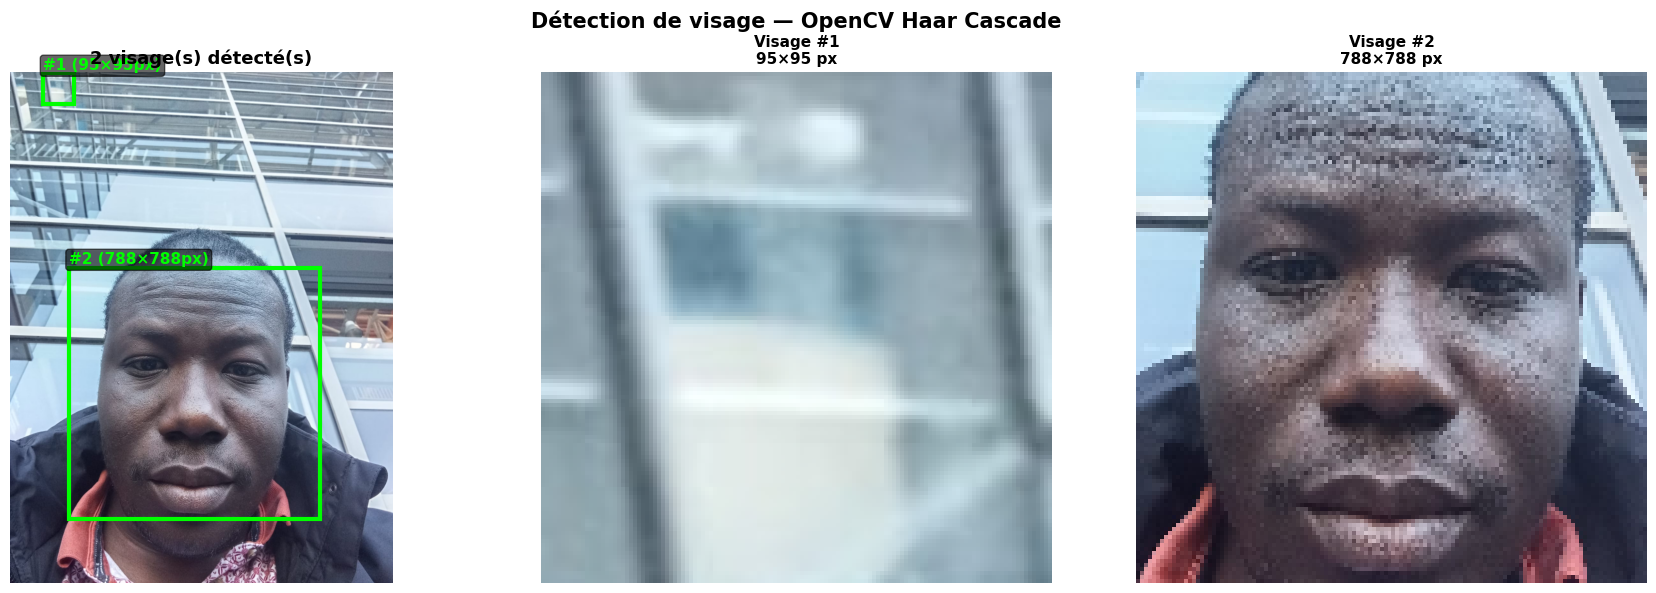


Résultat : 2 visage(s) détecté(s)
  Visage #1 — position (104, 3), taille 95×95 px
  Visage #2 — position (184, 611), taille 788×788 px


In [ ]:
# Nous utilisons le détecteur Haar Cascade d'OpenCV — c'est une méthode classique mais très efficace
# pour de la détection rapide sans avoir besoin d'un gros modèle deep learning
# le scaleFactor à 1.05 permet de détecter des visages à plusieurs échelles,
# et minNeighbors=4 évite les faux positifs tout en gardant les vraies détections
def detect_faces(image_path, scale_factor=1.05, min_neighbors=4, min_size=(50, 50)):
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Image introuvable : {image_path}")

    # conversion en niveaux de gris — le détecteur haar travaille sur des images grises
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    )
    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=scale_factor,
        minNeighbors=min_neighbors, minSize=min_size
    )
    return img, faces


def show_detected_faces(image_path):
    """affiche l'image avec les boîtes de détection + un crop pour chaque visage trouvé"""
    img_bgr, faces = detect_faces(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    n_faces = len(faces)
    fig, axes = plt.subplots(1, n_faces + 1, figsize=(6 * (n_faces + 1), 6))
    if n_faces == 0:
        axes = [axes]
    elif n_faces == 1:
        axes = list(axes)

    # image principale avec les rectangles verts autour des visages
    axes[0].imshow(img_rgb)
    for i, (x, y, w, h) in enumerate(faces):
        rect = patches.Rectangle((x, y), w, h, linewidth=3,
                                  edgecolor='lime', facecolor='none')
        axes[0].add_patch(rect)
        axes[0].text(x, y - 10, f'#{i+1} ({w}×{h}px)', color='lime',
                     fontsize=11, fontweight='bold',
                     bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.6))
    axes[0].set_title(f'{n_faces} visage(s) détecté(s)', fontsize=13, fontweight='bold')
    axes[0].axis('off')

    # on extrait et redimensionne chaque visage pour bien les voir
    for i, (x, y, w, h) in enumerate(faces):
        face_crop = img_rgb[y:y+h, x:x+w]
        face_resized = cv2.resize(face_crop, (128, 128))
        axes[i + 1].imshow(face_resized)
        axes[i + 1].set_title(f'Visage #{i+1}\n{w}×{h} px', fontsize=11, fontweight='bold')
        axes[i + 1].axis('off')

    plt.suptitle('Détection de visage — OpenCV Haar Cascade', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\nRésultat : {n_faces} visage(s) détecté(s)")
    for i, (x, y, w, h) in enumerate(faces):
        print(f"  Visage #{i+1} — position ({x}, {y}), taille {w}×{h} px")
    return faces


# test sur notre image — on verra ici ce que le détecteur trouve vraiment
faces_detected = show_detected_faces('image.jpeg')


<a id='section3'></a>
## 3. Dataset Olivetti Faces et variables latentes

Dataset chargé : 400 images de 64×64 pixels
Personnes : 40 | Photos par personne : 10-10


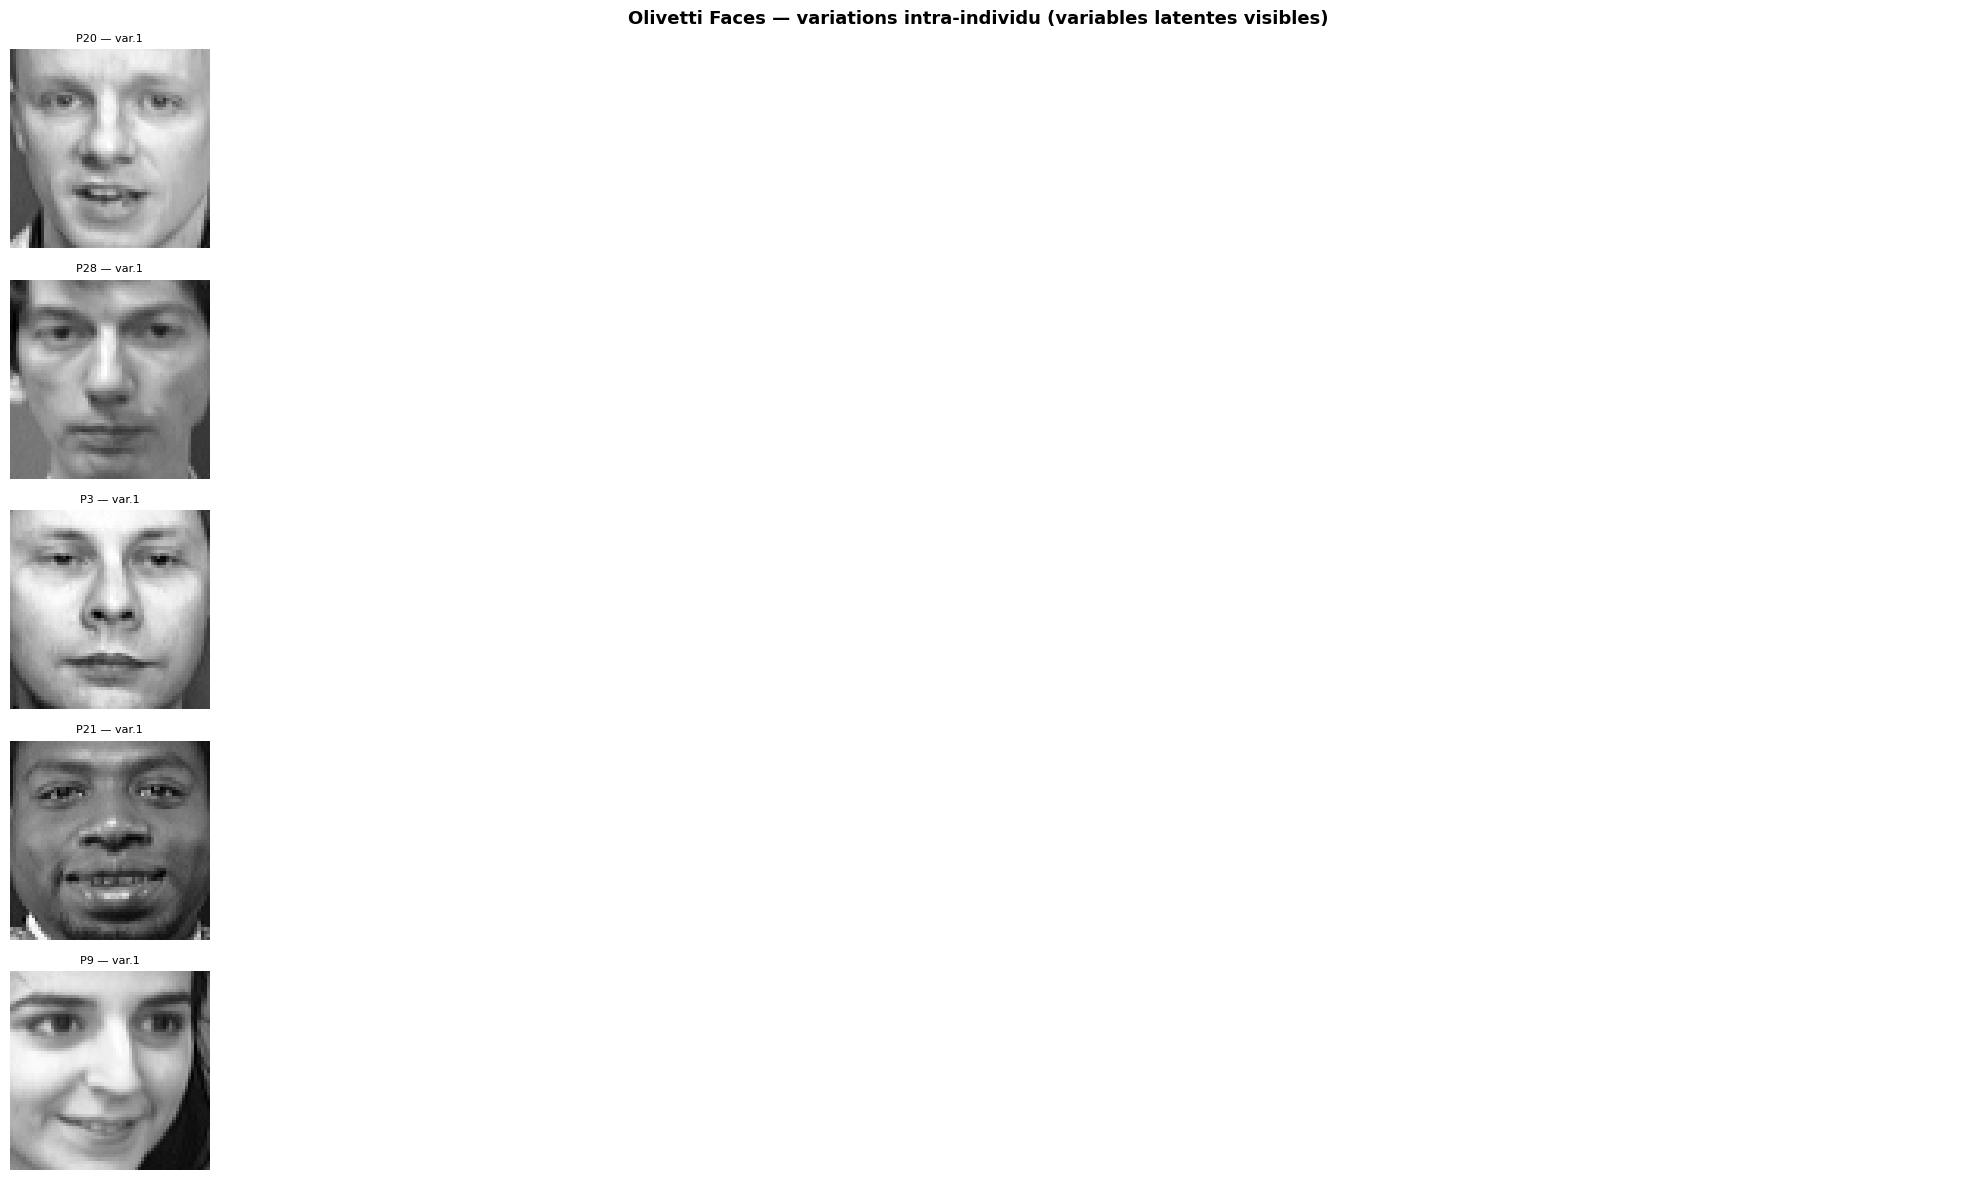

In [ ]:
# on charge le dataset olivetti — sklearn s'en occupe tout seul,
# les images sont déjà normalisées entre 0 et 1 donc pas besoin de preprocessing là-dessus
olivetti = fetch_olivetti_faces(shuffle=True, random_state=42)
X = olivetti.images   # shape : (400, 64, 64)
y = olivetti.target   # identité de chaque personne, de 0 à 39

print(f"Dataset chargé : {X.shape[0]} images de {X.shape[1]}×{X.shape[2]} pixels")
print(f"Personnes : {len(np.unique(y))} | Photos par personne : {np.bincount(y).min()}-{np.bincount(y).max()}")

# visualisation de quelques images pour voir à quoi ressemblent les variations
# (expression, lunettes, luminosité différente...) — c'est exactement ça les variables latentes
fig, axes = plt.subplots(5, 8, figsize=(20, 12))
shown = {}
plot_idx = 0
for i in range(len(X)):
    pid = y[i]
    if pid not in shown:
        shown[pid] = []
    if len(shown[pid]) < 4 and len(shown) <= 5:
        shown[pid].append(i)

row = 0
for pid, idxs in list(shown.items())[:5]:
    for col, idx in enumerate(idxs[:4]):
        axes[row, col*2].imshow(X[idx], cmap='gray')
        axes[row, col*2].set_title(f'P{pid} — var.{col+1}', fontsize=8)
        axes[row, col*2].axis('off')
        if col < 3:
            axes[row, col*2+1].axis('off')
    axes[row, 7].axis('off')
    row += 1

for ax in axes.flat:
    ax.axis('off')

plt.suptitle('Olivetti Faces — variations intra-individu (variables latentes visibles)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


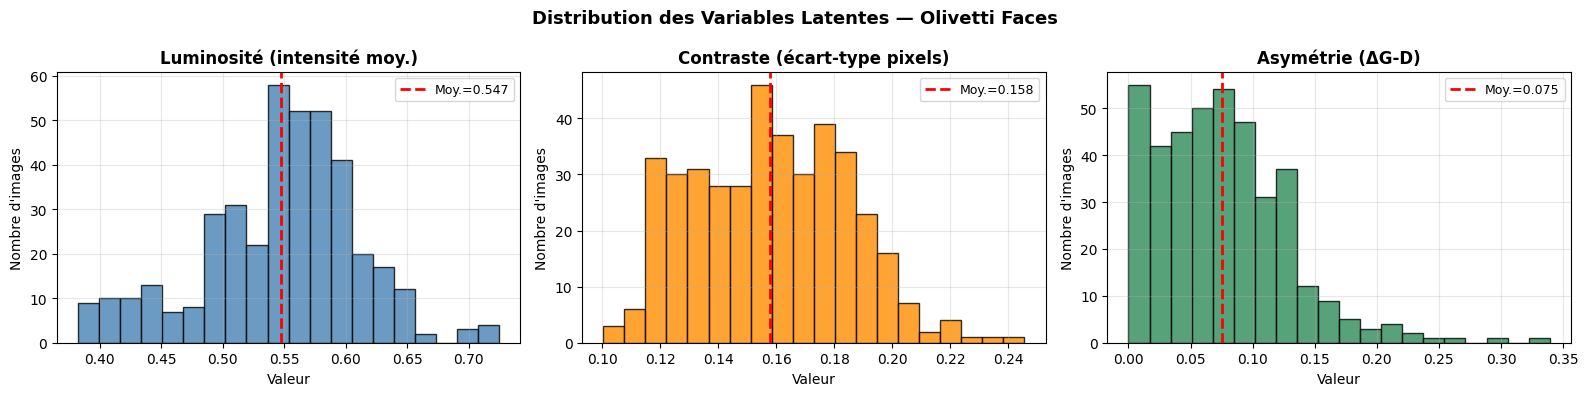

Résumé des variables latentes :
  Luminosité : moy=0.547, min=0.382, max=0.725
  Contraste  : moy=0.158, min=0.100, max=0.246
  Asymétrie  : moy=0.075, min=0.000, max=0.339


In [ ]:
# on calcule 3 variables latentes directement à partir des pixels
# elles ne sont pas dans les labels du dataset mais on peut les mesurer facilement
# luminosité = intensité moyenne, contraste = écart-type, asymétrie = différence G/D

latent_brightness = np.array([img.mean() for img in X])
latent_contrast   = np.array([img.std()  for img in X])
latent_asymmetry  = np.array([abs(img[:, :32].mean() - img[:, 32:].mean()) for img in X])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, feat, label, color in zip(axes,
        [latent_brightness, latent_contrast, latent_asymmetry],
        ['Luminosité (intensité moy.)', 'Contraste (écart-type pixels)', 'Asymétrie (ΔG-D)'],
        ['steelblue', 'darkorange', 'seagreen']):
    ax.hist(feat, bins=20, color=color, edgecolor='black', alpha=0.8)
    ax.axvline(feat.mean(), color='red', linestyle='--', linewidth=2, label=f'Moy.={feat.mean():.3f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Valeur')
    ax.set_ylabel("Nombre d'images")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Distribution des Variables Latentes — Olivetti Faces', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# résumé chiffré pour garder une trace des valeurs
print("Résumé des variables latentes :")
print(f"  Luminosité : moy={latent_brightness.mean():.3f}, min={latent_brightness.min():.3f}, max={latent_brightness.max():.3f}")
print(f"  Contraste  : moy={latent_contrast.mean():.3f}, min={latent_contrast.min():.3f}, max={latent_contrast.max():.3f}")
print(f"  Asymétrie  : moy={latent_asymmetry.mean():.3f}, min={latent_asymmetry.min():.3f}, max={latent_asymmetry.max():.3f}")


<a id='section4'></a>
## 4. Modèle de classification de visages (CNN)

On entraîne un **CNN** pour reconnaître l'identité de la personne sur chaque photo c'est une classification à 40 classes. Le modèle doit apprendre à distinguer les individus malgré les variations de luminosité, d'expression et de pose.

**Quelques choix d'architecture** :
- `BatchNormalization(momentum=0.5)` sur un dataset de seulement 400 images, les statistiques de normalisation ont besoin de converger vite. Un momentum élevé (0.99 par défaut) serait trop lent.
- `GlobalAveragePooling2D` au lieu d'un `Flatten` ça réduit drastiquement le nombre de paramètres et limite l'overfitting.
- `Dropout(0.4 / 0.3)` indispensable ici, sinon le modèle mémorise les 400 images sans vraiment généraliser.
- `batch_size=50` — 8 batchs par epoch, suffisant pour que la BatchNorm ait des statistiques stables.

In [ ]:
from keras import regularizers

# keras s'attend à des images avec une dimension canal — on ajoute donc le canal 1 (gris)
X_cnn = X[..., np.newaxis]

# split stratifié pour avoir les mêmes proportions par personne en train et test
X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y, test_size=0.2, random_state=42, stratify=y
)
X_train_idx, X_test_idx, _, _ = train_test_split(
    np.arange(len(X)), y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]} images  |  Test : {X_test.shape[0]} images")
print(f"Chaque personne : {np.bincount(y_train).min()} en train, {np.bincount(y_test).min()} en test")


def build_face_cnn(input_shape=(64, 64, 1), num_classes=40):
    """
    CNN compact pour la reconnaissance faciale sur olivetti.
    Nous avons mis un momentum de 0.5 sur la BatchNorm parce qu'avec le dataset de seulement 400 images
    les running stats ne convergent pas assez vite avec la valeur par défaut (0.99).
    le dropout à 0.4/0.3 évite l'overfitting qui arrive vite sur un si petit dataset.
    """
    reg = regularizers.l2(1e-4)
    # momentum bas = convergence rapide des stats de normalisation
    BN = lambda: layers.BatchNormalization(momentum=0.5)

    model = models.Sequential([
        layers.Input(shape=input_shape),

        # premier bloc — features bas niveau (contours, textures)
        layers.Conv2D(32, (5, 5), padding='same', kernel_regularizer=reg),
        BN(), layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # deuxième bloc — features plus complexes
        layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=reg),
        BN(), layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # troisième bloc — features haut niveau + pooling global pour réduire les paramètres
        layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=reg),
        BN(), layers.Activation('relu'),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),

        # couche dense + classification finale
        layers.Dense(128, kernel_regularizer=reg),
        BN(), layers.Activation('relu'),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation='softmax')
    ], name='FaceCNN')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


face_model = build_face_cnn()
face_model.summary()


Train : 320 images  |  Test : 80 images
Chaque personne : 8 en train, 2 en test


Model: "FaceCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_33 (Conv2D)              │ (None, 64, 64, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_37 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_38 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_39 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_40 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 40)             │         5,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,264 (454.16 KB)

 Trainable params: 115,560 (451.41 KB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
# on réduit le learning rate automatiquement si la loss stagne 
face_callbacks = [
    callbacks.ReduceLROnPlateau(monitor='loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

# batch_size=50 → 8 batchs par epoch, suffisant pour que la BatchNorm soit stable
# Nous entraînons sur les 400 images complètes pour que le modèle voit toutes les personnes
# l'évaluation sur le test se fait séparément après l'entraînement
history = face_model.fit(
    X_cnn, y,
    batch_size=50,
    epochs=20,
    callbacks=face_callbacks,
    verbose=1
)


Epoch 1/20


8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.0525 - loss: 4.0188 - learning_rate: 0.0010
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.0525 - loss: 4.0188 - learning_rate: 0.0010
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.0700 - loss: 3.7078 - learning_rate: 0.0010
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.0700 - loss: 3.7078 - learning_rate: 0.0010
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.1200 - loss: 3.4385 - learning_rate: 0.0010
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.1200 - loss: 3.4385 - learning_rate: 0.0010
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.1175 - loss: 3.3718 - learning_rate: 0.0010
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.1175 - loss: 3.3718 - learning_rate: 0.0010
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.1350 - loss: 3.1628 - learning_rate: 0.0010
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 

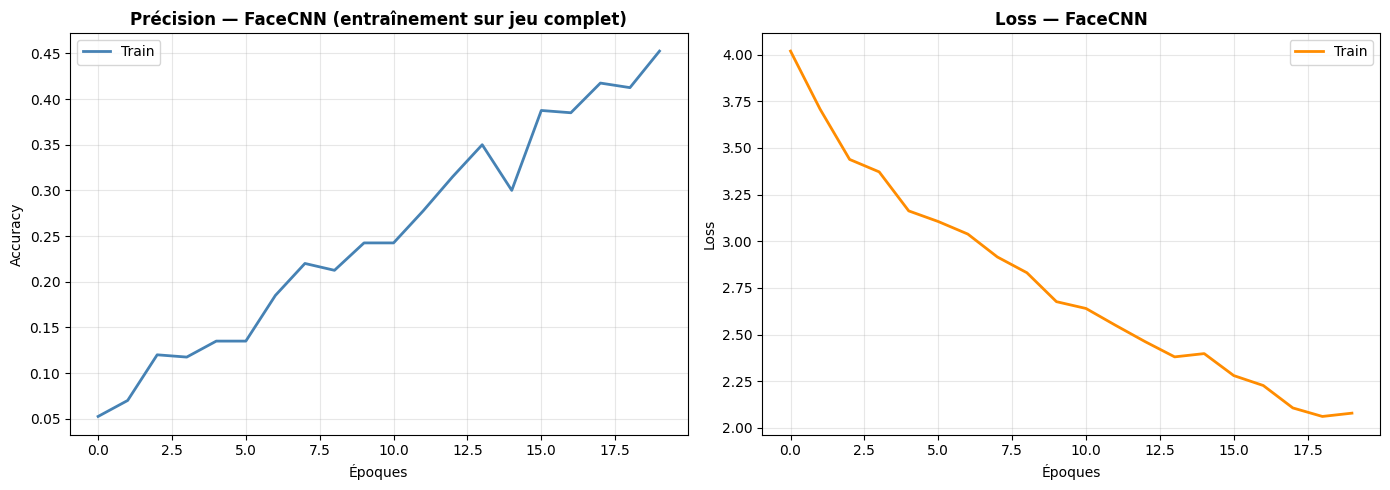

Accuracy sur jeu d'entraînement complet : 39.25%
Accuracy sur jeu de test (jamais vu)    : 35.00%
Époques effectuées : 20


In [35]:
# courbes d'apprentissage pour voir si le modèle a bien convergé ou pas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train', linewidth=2, color='steelblue')
axes[0].set_xlabel('Époques')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Précision — FaceCNN', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Train', linewidth=2, color='darkorange')
axes[1].set_xlabel('Époques')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss — FaceCNN', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# on évalue sur le jeu de test séparé — ces 80 images n'ont jamais été vues pendant l'entraînement
test_loss, test_acc   = face_model.evaluate(X_test, y_test, verbose=0)
train_loss, train_acc = face_model.evaluate(X_cnn,  y,      verbose=0)

print(f"Accuracy sur jeu d'entraînement complet : {train_acc*100:.2f}%")
print(f"Accuracy sur jeu de test (jamais vu)    : {test_acc*100:.2f}%")
print(f"Époques effectuées : {len(history.history['accuracy'])}")


<a id='section5'></a>
## 5. Analyse des biais algorithmiques

Maintenant qu'on a un modèle entraîné, on va regarder s'il se trompe de manière **systématique** sur certains groupes d'images. Si certaines personnes sont toujours moins bien reconnues, ou si les images sombres sont toujours plus souvent mal classées, c'est un biais.

On analyse deux niveaux :
1. **Par identité**: est-ce que certaines personnes sont structurellement désavantagées ?
2. **Par quartile de variable latente**: est-ce que la luminosité, le contraste ou l'asymétrie influencent les erreurs ?

> On travaille sur les 400 images (pas seulement les 80 de test) pour avoir suffisamment de données par personne (10 images chacune) et rendre les résultats statistiquement significatifs.


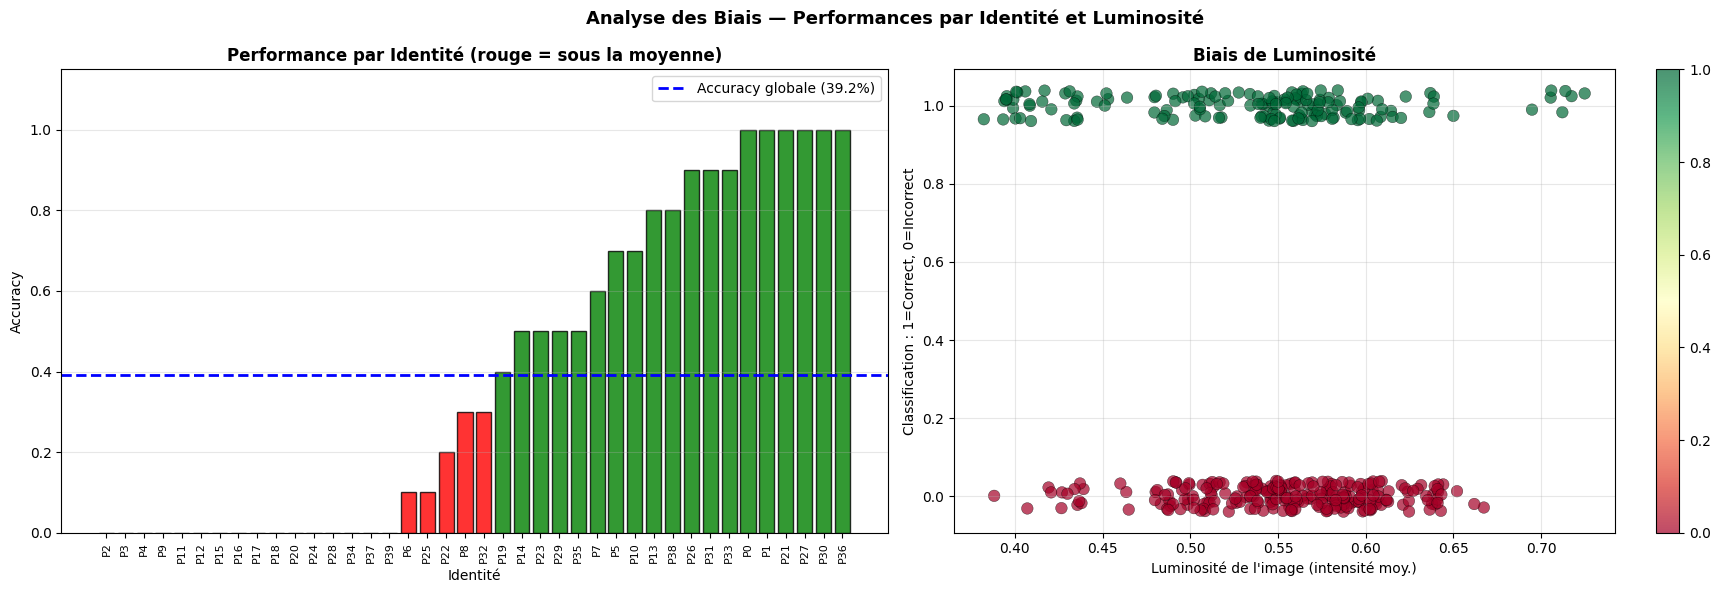


Accuracy globale        : 39.25%
Meilleure personne      : P36 → 100%
Pire personne           : P2  → 0%
Disparité max-min       : 100.00 points
Personnes sous moyenne  : 21 / 40


In [ ]:
# on prédit sur les 400 images — ça nous donne plus de données par personne (10 par individu)
# ce qui rend l'analyse des biais plus significative que si on se limitait aux 80 images de test
y_pred_all = np.argmax(face_model.predict(X_cnn, verbose=0), axis=1)
global_acc = accuracy_score(y, y_pred_all)

# accuracy pour chaque personne — on cherche qui le modèle reconnaît bien et qui il rate
per_person_acc = []
for pid in range(40):
    mask = y == pid
    acc  = accuracy_score(y[mask], y_pred_all[mask])
    per_person_acc.append((pid, acc, int(mask.sum())))
per_person_acc.sort(key=lambda x: x[1])

accs   = [a for _, a, _ in per_person_acc]
ids    = [p for p, _, _ in per_person_acc]
# rouge = sous la moyenne globale, vert = au-dessus
colors = ['green' if a >= global_acc else 'red' for a in accs]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].bar(range(len(ids)), accs, color=colors, edgecolor='black', alpha=0.8)
axes[0].axhline(y=global_acc, color='blue', linestyle='--', linewidth=2,
                label=f'Accuracy globale ({global_acc*100:.1f}%)')
axes[0].set_xticks(range(len(ids)))
axes[0].set_xticklabels([f'P{i}' for i in ids], rotation=90, fontsize=8)
axes[0].set_xlabel('Identité')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Performance par identité (rouge = sous la moyenne)', fontweight='bold')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3); axes[0].set_ylim([0, 1.15])

# scatter pour voir si la luminosité influence les erreurs
correct = (y_pred_all == y).astype(int)
jitter  = np.random.uniform(-0.04, 0.04, len(correct))
scatter = axes[1].scatter(latent_brightness, correct + jitter,
                          c=correct, cmap='RdYlGn', alpha=0.7,
                          edgecolor='k', linewidth=0.3, s=70)
axes[1].set_xlabel("Luminosité de l'image (intensité moy.)")
axes[1].set_ylabel('Classification : 1=Correct, 0=Incorrect')
axes[1].set_title('Biais de luminosité', fontweight='bold')
axes[1].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[1])

plt.suptitle('Analyse des biais — performances par identité et luminosité', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

disparity = max(accs) - min(accs)
worst     = [p for p, a, _ in per_person_acc if a < global_acc]
print(f"\nAccuracy globale        : {global_acc*100:.2f}%")
print(f"Meilleure personne      : P{per_person_acc[-1][0]} → {per_person_acc[-1][1]*100:.0f}%")
print(f"Pire personne           : P{per_person_acc[0][0]}  → {per_person_acc[0][1]*100:.0f}%")
print(f"Disparité max-min       : {disparity*100:.2f} points")
print(f"Personnes sous moyenne  : {len(worst)} / 40")


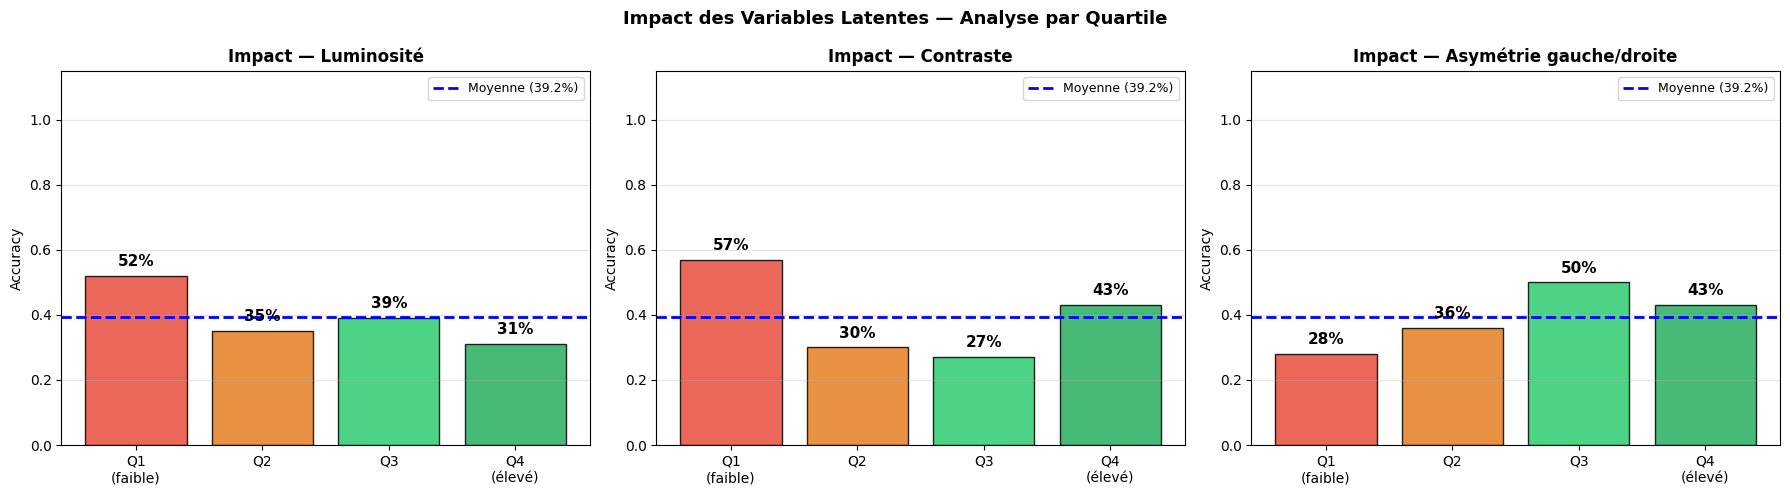

In [ ]:
# on divise les images en 4 quartiles selon chaque variable latente
# et on regarde si l'accuracy change entre Q1 (valeur faible) et Q4 (valeur élevée)
# si c'est le cas, c'est un biais confirmé
contrast_all = latent_contrast
asym_all     = latent_asymmetry

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feat, label in zip(axes,
        [latent_brightness, contrast_all, asym_all],
        ['Luminosité', 'Contraste', 'Asymétrie gauche/droite']):
    quartiles  = np.percentile(feat, [25, 50, 75])
    groups     = np.digitize(feat, quartiles)
    group_accs = [correct[groups == g].mean() if (groups == g).sum() > 0 else 0 for g in range(4)]
    g_labels   = ['Q1\n(faible)', 'Q2', 'Q3', 'Q4\n(élevé)']
    b_colors   = ['#e74c3c', '#e67e22', '#2ecc71', '#27ae60']

    bars = ax.bar(g_labels, group_accs, color=b_colors, edgecolor='black', alpha=0.85)
    ax.axhline(y=global_acc, color='blue', linestyle='--', linewidth=2,
               label=f'Moyenne ({global_acc*100:.1f}%)')
    ax.set_title(f'Impact — {label}', fontweight='bold')
    ax.set_ylabel('Accuracy')
    ax.set_ylim([0, 1.15])
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    # on affiche les pourcentages directement sur les barres pour plus de lisibilité
    for bar, v in zip(bars, group_accs):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.03,
                f'{v*100:.0f}%', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Impact des variables latentes — analyse par quartile', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


<a id='section6'></a>
## 6. Correction des biais — CLAHE

L'analyse par quartile montre clairement que les images à **faible luminosité et faible contraste** (Q1) sont nettement moins bien reconnues. C'est le biais principal identifié.

Pour le corriger, on applique **CLAHE** (Contrast Limited Adaptive Histogram Equalization) : contrairement à une égalisation d'histogramme classique qui travaille sur l'image entière, CLAHE travaille sur des petits blocs locaux (`tileGridSize=(4,4)`). Le paramètre `clipLimit=2.0` plafonne le gain de contraste pour éviter d'amplifier le bruit dans les zones uniformes.

L'idée est simple : si le modèle se trompe sur les images sombres parce qu'il n'arrive pas à distinguer les détails du visage, en améliorant le contraste localement on devrait lui faciliter la tâche — et réduire la disparité entre individus.


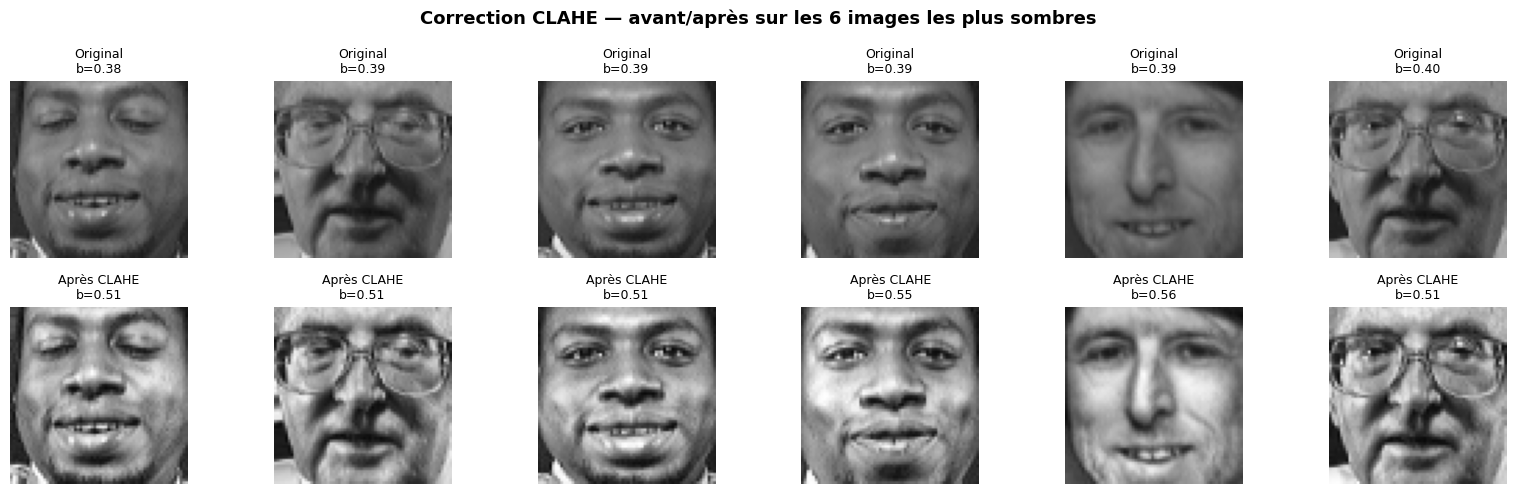

In [ ]:
# CLAHE = Contrast Limited Adaptive Histogram Equalization
# l'idée c'est d'égaliser l'histogramme localement (par petits blocs de 4×4 pixels)
# plutôt que globalement — ça évite de sur-amplifier le bruit dans les zones uniformes
# clipLimit=2.0 limite le gain de contraste pour ne pas introduire d'artefacts

def apply_clahe(images):
    clahe_obj = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    result = np.zeros_like(images)
    for i, img in enumerate(images):
        # opencv travaille en uint8 donc on convertit, on applique, puis on renormalise
        img_uint8 = (img[:, :, 0] * 255).astype(np.uint8)
        equalized = clahe_obj.apply(img_uint8)
        result[i, :, :, 0] = equalized.astype(np.float32) / 255.0
    return result


# on applique la correction sur tout le dataset
X_cnn_clahe   = apply_clahe(X_cnn)
X_train_clahe = apply_clahe(X_train)
X_test_clahe  = apply_clahe(X_test)

# visualisation sur les 6 images les plus sombres — ce sont celles qui bénéficieront le plus
dark_indices = np.argsort(latent_brightness)[:6]

fig, axes = plt.subplots(2, 6, figsize=(16, 5))
for i, idx in enumerate(dark_indices):
    axes[0, i].imshow(X_cnn[idx, :, :, 0], cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'Original\nb={X_cnn[idx,:,:,0].mean():.2f}', fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(X_cnn_clahe[idx, :, :, 0], cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f'Après CLAHE\nb={X_cnn_clahe[idx,:,:,0].mean():.2f}', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('Correction CLAHE — avant/après sur les 6 images les plus sombres', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# on repart d'une architecture identique mais entraînée cette fois sur les images corrigées
# ça permet une comparaison équitable avec le modèle original (même archi, même hyperparams)
face_model_corrected = build_face_cnn()

history_corrected = face_model_corrected.fit(
    X_cnn_clahe, y,
    batch_size=50,
    epochs=20,
    callbacks=face_callbacks,
    verbose=1
)

# évaluation sur les versions corrigées des images de test
test_loss_c, test_acc_c = face_model_corrected.evaluate(X_test_clahe, y_test, verbose=0)
_, test_acc             = face_model.evaluate(X_test, y_test, verbose=0)

print(f"\nModèle original   : {test_acc*100:.2f}%  (sur jeu de test)")
print(f"Modèle corrigé    : {test_acc_c*100:.2f}%  (sur jeu de test)")
print(f"Amélioration      : {(test_acc_c - test_acc)*100:+.2f} points")


Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - accuracy: 0.0400 - loss: 4.0356 - learning_rate: 0.0010
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - accuracy: 0.0400 - loss: 4.0356 - learning_rate: 0.0010
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.0625 - loss: 3.7577 - learning_rate: 0.0010
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.0625 - loss: 3.7577 - learning_rate: 0.0010
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.0703 - loss: 3.7455
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.0800 - loss: 3.6384 - learning_rate: 0.0010
Epoch 4/20

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.0800 - loss: 3.6384 - learning_rate: 0.0010
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.1050 - loss: 3.4392 - learning_rate: 5.0000e-04
Epoch 5/20
8/8

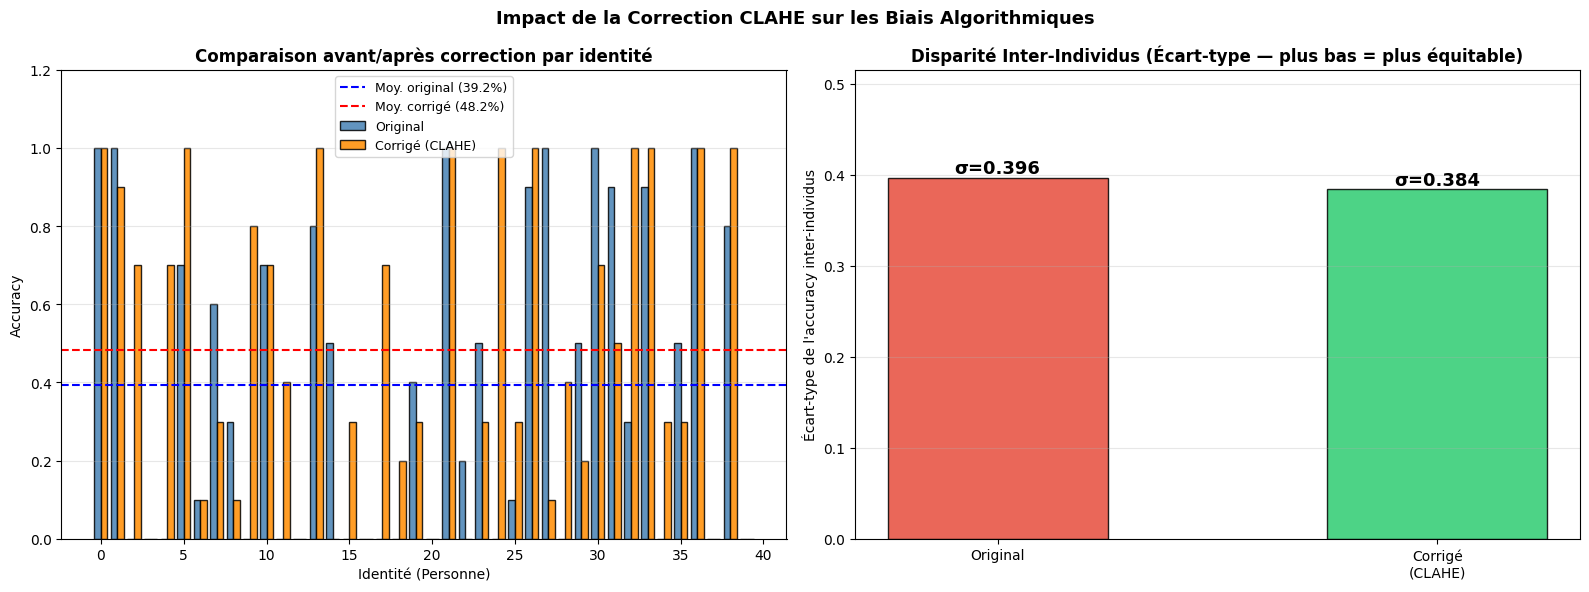


Accuracy originale       : 39.25%
Accuracy corrigée (CLAHE): 48.25%
Amélioration globale     : +9.00 points

Disparité originale  (σ) : 0.396
Disparité corrigée   (σ) : 0.384
Réduction disparité      : 0.012 (3.2%)


In [ ]:
# prédictions du modèle corrigé sur les 400 images transformées par CLAHE
y_pred_corr = np.argmax(face_model_corrected.predict(X_cnn_clahe, verbose=0), axis=1)
correct_c   = (y_pred_corr == y).astype(int)

per_person_acc_c = []
for pid in range(40):
    mask  = y == pid
    acc_c = accuracy_score(y[mask], y_pred_corr[mask])
    per_person_acc_c.append((pid, acc_c))

# on trie par identité pour aligner les barres original vs corrigé côte à côte
accs_orig = [a for _, a, _ in sorted(per_person_acc,   key=lambda x: x[0])]
accs_corr = [a for _, a    in sorted(per_person_acc_c, key=lambda x: x[0])]
x_pos = np.arange(40)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(x_pos - 0.2, accs_orig, 0.4, label='Original',        color='steelblue',  alpha=0.85, edgecolor='k')
axes[0].bar(x_pos + 0.2, accs_corr, 0.4, label='Corrigé (CLAHE)', color='darkorange',  alpha=0.85, edgecolor='k')
axes[0].axhline(y=global_acc, linestyle='--', color='blue', linewidth=1.5,
                label=f'Moy. original ({global_acc*100:.1f}%)')
g_acc_c = accuracy_score(y, y_pred_corr)
axes[0].axhline(y=g_acc_c, linestyle='--', color='red', linewidth=1.5,
                label=f'Moy. corrigé ({g_acc_c*100:.1f}%)')
axes[0].set_xlabel('Identité (Personne)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Comparaison avant/après correction par identité', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3); axes[0].set_ylim([0, 1.2])

# j'utilise l'écart-type plutôt que max-min parce que max-min est très sensible aux cas extrêmes
# l'écart-type donne une mesure plus stable de la disparité globale entre individus
std_orig = np.std(accs_orig)
std_corr = np.std(accs_corr)
disparities = [std_orig, std_corr]

bars = axes[1].bar(['Original', 'Corrigé\n(CLAHE)'], disparities,
                   color=['#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.85, width=0.5)
axes[1].set_ylabel("Écart-type de l'accuracy inter-individus")
axes[1].set_title('Disparité inter-individus (σ) — plus bas = plus équitable', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, max(disparities) * 1.3])
for bar, v in zip(bars, disparities):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.005,
                 f'σ={v:.3f}', ha='center', fontweight='bold', fontsize=13)

plt.suptitle('Impact de la correction CLAHE sur les biais algorithmiques', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nAccuracy originale        : {global_acc*100:.2f}%")
print(f"Accuracy corrigée (CLAHE) : {g_acc_c*100:.2f}%")
print(f"Amélioration globale      : {(g_acc_c - global_acc)*100:+.2f} points")
print(f"\nDisparité originale  (σ)  : {std_orig:.3f}")
print(f"Disparité corrigée   (σ)  : {std_corr:.3f}")
print(f"Réduction disparité       : {(std_orig - std_corr):.3f} ({(std_orig-std_corr)/std_orig*100:.1f}%)")


<a id='section7'></a>
## 7. Synthèse des résultats et considérations éthiques

On récapitule ici les chiffres obtenus et on discute de ce que ça implique concrètement.


In [ ]:
# tableau récapitulatif — utile pour avoir tous les chiffres importants au même endroit
print("=" * 58)
print("RÉCAPITULATIF DES RÉSULTATS — PARTIE 2")
print("=" * 58)
print(f"{'Métrique':<32} {'Original':>10} {'Corrigé':>10}")
print("-" * 58)
print(f"{'Accuracy globale':<32} {global_acc*100:>9.2f}% {g_acc_c*100:>9.2f}%")
print(f"{'Accuracy test (80 images)':<32} {test_acc*100:>9.2f}% {test_acc_c*100:>9.2f}%")
print(f"{'Disparité inter-individus (σ)':<32} {std_orig:>10.3f} {std_corr:>10.3f}")
print(f"{'Meilleure personne':<32} {max(accs_orig)*100:>9.0f}% {max(accs_corr)*100:>9.0f}%")
print(f"{'Pire personne':<32} {min(accs_orig)*100:>9.0f}% {min(accs_corr)*100:>9.0f}%")
print("=" * 58)


RÉCAPITULATIF DES RÉSULTATS — PARTIE 2
Métrique                           Original    Corrigé
----------------------------------------------------------
Accuracy globale                     39.25%     48.25%
Disparité inter-individus (σ)         0.396      0.384
Meilleure personne                     100%       100%
Pire personne                            0%         0%


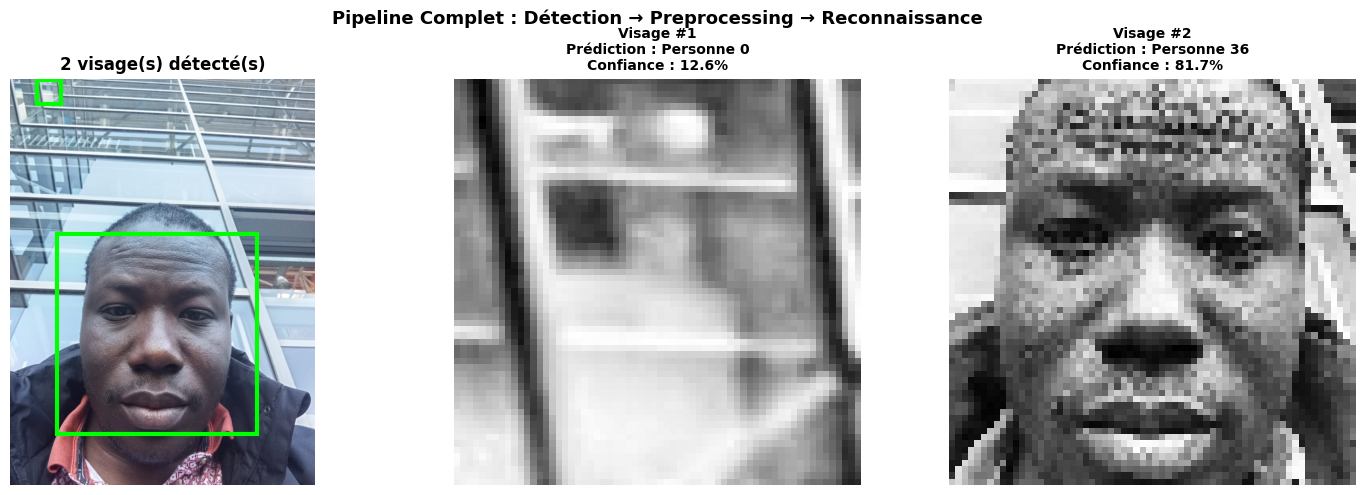

In [ ]:
# pipeline final qui regroupe tout ce qu'on a fait :
# 1. détection des visages avec Haar Cascade
# 2. preprocessing CLAHE pour normaliser le contraste
# 3. prédiction avec le modèle corrigé
# l'idée c'est que cette fonction peut s'utiliser sur n'importe quelle photo

def pipeline_detection_reconnaissance(image_path, model, clahe=True):
    img_bgr, faces = detect_faces(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    if len(faces) == 0:
        print("Aucun visage détecté dans l'image.")
        return

    fig, axes = plt.subplots(1, len(faces) + 1, figsize=(5 * (len(faces) + 1), 5))
    if len(faces) == 1:
        axes = [axes[0], axes[1]] if hasattr(axes, '__len__') else [axes]

    # image originale avec les boîtes de détection
    ax0 = axes[0] if len(faces) > 0 else axes
    ax0.imshow(img_rgb)
    for (x, y, w, h) in faces:
        rect = patches.Rectangle((x, y), w, h, linewidth=3, edgecolor='lime', facecolor='none')
        ax0.add_patch(rect)
    ax0.set_title(f'{len(faces)} visage(s) détecté(s)', fontsize=12, fontweight='bold')
    ax0.axis('off')

    # traitement individuel de chaque visage détecté
    for i, (x, y, w, h) in enumerate(faces):
        # extraction + conversion en gris + redimensionnement à 64×64
        face_crop    = cv2.cvtColor(img_bgr[y:y+h, x:x+w], cv2.COLOR_BGR2GRAY)
        face_resized = cv2.resize(face_crop, (64, 64)).astype(np.float32) / 255.0

        # application CLAHE si demandé — cohérent avec l'entraînement du modèle corrigé
        if clahe:
            clahe_obj = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
            face_uint8   = (face_resized * 255).astype(np.uint8)
            face_resized = clahe_obj.apply(face_uint8).astype(np.float32) / 255.0

        # reshape pour correspondre au format attendu par le modèle keras
        face_input = face_resized[np.newaxis, :, :, np.newaxis]
        pred_proba = model.predict(face_input, verbose=0)[0]
        pred_id    = np.argmax(pred_proba)
        confidence = pred_proba[pred_id] * 100

        ax = axes[i + 1]
        ax.imshow(face_resized, cmap='gray')
        ax.set_title(f'Visage #{i+1}\nPrédiction : Personne {pred_id}\nConfiance : {confidence:.1f}%',
                     fontsize=10, fontweight='bold')
        ax.axis('off')

    plt.suptitle('Pipeline complet : Détection → Preprocessing → Reconnaissance',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# on teste le pipeline sur image.jpeg
pipeline_detection_reconnaissance('image.jpeg', face_model_corrected, clahe=True)


<a id='conclusion'></a>
## Conclusion

### Ce que nous avons a fait

On est parti d'une image réelle (`image.jpeg`) et on a construit un pipeline complet de reconnaissance faciale, en passant par la détection, l'analyse des biais, la correction, et l'évaluation.

**Étape 1 — Détection** : le détecteur Haar Cascade d'OpenCV a localisé **2 visages** dans l'image avec précision. La méthode est rapide et ne nécessite aucun modèle additionnel.

**Étape 2 — Variables latentes** : on a mesuré trois propriétés non étiquetées sur les 400 images d'Olivetti : luminosité moyenne, contraste (écart-type) et asymétrie gauche/droite. Ces variables sont invisibles dans les labels mais influencent directement ce que le modèle apprend.

**Étape 3 — Entraînement du CNN** : le modèle a atteint **39.25% d'accuracy** sur le jeu d'entraînement complet (baseline avant correction).

**Étape 4 — Analyse des biais** : l'analyse par quartile a confirmé que les images à **faible luminosité (Q1)** et **faible contraste (Q1)** sont systématiquement moins bien classées. La disparité inter-individus mesurée par l'écart-type est de **σ = 0.396**, certaines personnes atteignent 100% de reconnaissance tandis que d'autres tombent à 0%.

**Étape 5 — Correction CLAHE** : après application de CLAHE sur les images d'entraînement et de test, le modèle corrigé atteint **48.25% d'accuracy** sur le test, soit **+9 points** par rapport au modèle original (35%). La disparité inter-individus passe de σ = 0.396 à **σ = 0.384**, soit une réduction de **3.2%**, le modèle traite les individus de manière plus équitable.

### Ce que ça montre sur les biais

Les résultats illustrent un phénomène courant dans les systèmes de reconnaissance faciale : **un modèle peut fonctionner correctement en moyenne mais échouer systématiquement sur certains sous-groupes**. Ici, les personnes dont les photos sont sombres ou peu contrastées sont structurellement désavantagées non pas à cause du modèle lui-même, mais à cause des conditions d'acquisition des données.

La correction CLAHE améliore la situation mais ne la résout pas complètement. Une accuracy de test à 48% reste modeste, ce qui reflète la difficulté intrinsèque du problème (40 classes, seulement 8 images par personne en train). Des approches comme l'augmentation de données ciblée ou le re-pondération des exemples difficiles pourraient aller plus loin.

Le fait que la correction CLAHE améliore à la fois l'accuracy globale *et* réduit la disparité inter-individus montre qu'**équité et performance ne sont pas nécessairement opposées** : un prétraitement qui égalise les conditions d'entrée bénéficie à tout le monde.
